# EvalRX on a Colab TPU

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evalvitals/evalrx/blob/ruinan/examples/colab/archive/chartqa_diagnosis.ipynb)

Run **Gemma 4 E2B-it on ChartQA** with `evalrx run`. This notebook installs EvalRX, downloads a reproducible 64-question sample, runs diagnosis and L1 prompt-repair search, and displays the results here.

Choose **Runtime → Change runtime type → TPU**. Gemma runs on the TPU; **Gemini CLI runs as a coding-agent process in this Colab runtime**, configured with `gemini-2.5-flash` for reasoning. The raw agent transcript also records the model identifiers returned in usage statistics. EvalRX launches the agent for exploratory analysis and code generation. The same API model provides structured diagnosis and repair proposals.

Add `GEMINI_API_KEY` to Colab Secrets and enable this notebook's access, or enter it at the hidden prompt. No browser login is needed. Agent and judge calls use your API quota. Credentials are never embedded in notebook source or printed.

The 64 questions are split into 32 EXPLORE and 32 CONFIRM cases. A small tutorial sample can demonstrate the workflow without establishing a reliable accuracy gain. All outputs below come from executing these cells; no saved prediction file is loaded.

**Historical diagnosis run:** this saved run used Gemini CLI API-key authentication. It found no validated repair. The new TPU/GPU repair notebooks use Antigravity CLI (`agy`).

## 1. Install

In [1]:
import os, subprocess, sys
from pathlib import Path

repo = Path('/content/evalrx')
if not repo.exists():
    subprocess.run(['git', 'clone', '--branch', 'ruinan', '--depth', '1',
                    'https://github.com/evalvitals/evalrx.git', str(repo)], check=True)
os.chdir(repo)
os.environ.update(OMP_NUM_THREADS='2', PYTHONUNBUFFERED='1', TF_CPP_MIN_LOG_LEVEL='2',
                  MALLOC_ARENA_MAX='2', MALLOC_TRIM_THRESHOLD_='0')
def run_visible(command):
    with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as process:
        for line in process.stdout:
            print(line, end='', flush=True)
        if process.wait():
            raise subprocess.CalledProcessError(process.returncode, command)

run_visible(['bash', 'tools/colab/setup.sh'])
run_visible([sys.executable, '-m', 'pip', 'install', '-q', '-c',
                str(Path.home() / '.cache/evalrx/colab/constraints.txt'),
                '-e', '.[data,contract,viz,stats,gemini]'])

# Colab provides Node under /tools/node/bin even when it is absent from PATH.
import shutil
if Path('/tools/node/bin/node').exists():
    os.environ['PATH'] = '/tools/node/bin:' + os.environ['PATH']
assert shutil.which('npm'), 'Install Node.js 20 or newer and npm before continuing.'
run_visible(['npm', 'install', '-g', '@google/gemini-cli@0.46.0'])
run_visible(['gemini', '--version'])


Keeping runtime packages:


jax==0.7.2


jaxlib==0.7.2


libtpu==0.0.21.1


torch==2.9.0+cpu


...

  warnings.warn(


SETUP versions {'evalrx': '0.1.2', 'gemma': '4.0.1', 'jax': '0.7.2', 'jaxlib': '0.7.2', 'flax': '0.11.2', 'kauldron': '1.4.4', 'torch': '2.9.0+cpu'}


SETUP jax tpu [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


changed 7 packages in 3s


0.46.0


## 2. Check the TPU and launch the agent

Keep JAX in subprocesses so the notebook kernel does not retain TPU memory between commands. The agent preflight creates and executes a Python file in a separate workspace. Its tool transcript and generated source are retained below.


In [2]:
import hashlib, importlib.metadata
run_visible([sys.executable, '-c',
    "import jax; assert jax.default_backend() == 'tpu', 'Select a TPU runtime'; "
    "print('Backend:', jax.default_backend()); print('Devices:', [(str(d), d.device_kind) for d in jax.devices()])"])
print('EvalRX:', importlib.metadata.version('evalrx'))
print('Git base:', subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip())
print('Working tree modified:', bool(subprocess.check_output(['git', 'status', '--porcelain'], text=True).strip()))
for filename in ['evalrx/cli.py', 'evalrx/benchmark/runner.py', 'evalrx/models/backends/jax/adapters/gemma.py']:
    print(filename, hashlib.sha256(Path(filename).read_bytes()).hexdigest())

if not os.environ.get('GEMINI_API_KEY'):
    try:
        from google.colab import userdata
        os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')
    except Exception:
        import getpass
        os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API key: ')
assert os.environ['GEMINI_API_KEY'], 'An API key is required.'

from evalrx.agent_runtime.providers.gemini_cli import GeminiCliAgent
agent_dir = Path('/content/evalrx_agent_check')
agent = GeminiCliAgent(binary_path=shutil.which('gemini'), model='gemini-2.5-flash', timeout_sec=180)
result = agent.run(
    'Create agent_check.py containing a Python program that prints AGENT_READY. '
    'Execute it with python, verify its output, and report the command and result. '
    'Work only in this directory.', agent_dir,
)
print('Agent provider:', result.provider_name)
print(result.raw_output)
assert not result.error, result.error
assert (agent_dir / 'agent_check.py').exists(), 'Agent did not create the requested file.'
print((agent_dir / 'agent_check.py').read_text())
run_visible([sys.executable, str(agent_dir / 'agent_check.py')])


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")


  warnings.warn(


Backend: tpu


Devices: [('TPU_0(process=0,(0,0,0,0))', 'TPU v5 lite')]


EvalRX: 0.1.2
Git base: 4fa8752973b491ddf4d4290fbef876b1f70302ee


Working tree modified: True
evalrx/cli.py 6fa1087a425219727344d50929325c6321452a58c9693cb2fbcc166b9619e95a
evalrx/benchmark/runner.py 7c737d993e7a64da6198b1bad67a399486a3ff0f8ffe8ec8a4e3c8909b46b5f1
evalrx/models/backends/jax/adapters/gemma.py a1c5f4deae89e0c7a279668d6344e8654dc1055c87a0f791f312e913be218c0b


Agent provider: gemini_cli
{"type":"init","timestamp":"2026-10-05T21:07:23.475Z","session_id":"ec4f6815-23fa-4521-8f21-8124186addc0","model":"gemini-2.5-flash"}
{"type":"message","timestamp":"2026-10-05T21:07:23.476Z","role":"user","content":"Create agent_check.py containing a Python program that prints AGENT_READY. Execute it with python, verify its output, and report the command and result. Work only in this directory."}
{"type":"tool_use","timestamp":"2026-10-05T21:07:25.988Z","tool_name":"update_topic","tool_id":"update_topic__call_417987","parameters":{"strategic_intent":"Create agent_check.py, run it to verify AGENT_READY output, and report the results."}}
{"type":"tool_result","timestamp":"2026-10-05T21:07:26.030Z","tool_id":"update_topic__call_417987","status":"success","output":"> [!STRATEGY]\n> **Intent:** Create agent_check.py, run it to verify AGENT_READY output, and report the results."}
{"type":"tool_use","timestamp":"2026-10-05T21:07:27.274Z","tool_name":"write_file","to

## 3. Run EvalRX

The command downloads the pinned ChartQA revision, evaluates Gemma, runs M1 probing, agent-written exploratory analysis and M2 analysis, M3 diagnosis and M4 verification, then searches L1 prompt repairs and confirms one frozen candidate. Model weights stay unchanged.

`--skip-surgery` omits the separate surgery experiment; **M5 prompt-repair search still runs**. The repair search is restricted to L1 prompt changes to limit generation costs; analysis code generation is enabled. This does not guarantee a successful repair or sufficient memory for every run. Cold checkpoint loading and XLA compilation take several minutes. The terminal output remains in this cell.

For evaluation alone, add `--baseline-only` and omit the judge configuration; the diagnosis cells below assume the full run.

In [3]:
%%bash
set -euo pipefail
evalrx run \
  --modality vlm --model gemma-4-e2b --dataset chartqa \
  --backend jax_local --device tpu --dtype bfloat16 \
  --limit 64 --download-limit 64 --seed 5022 \
  --max-new-tokens 64 --temperature 0 \
  --judge-provider gemini --judge-model gemini-2.5-flash \
  --coder-provider gemini_cli --coder-model gemini-2.5-flash \
  --fix-tier L1 --fix-repair-rounds 1 --fix-validation-cases 32 \
  --allow-codegen --explore --m2-codegen --skip-surgery \
  --data-dir /content/evalrx_demo/data --run-dir /content/evalrx_demo/runs \
  --run-tag notebook


[model] Gemma 4 E2B-it, spec gemma-4-e2b-it = google/gemma-4-E2B-it; backend=jax_local; benchmark=ChartQA/test_human; n=64
judge: gemini model=gemini-2.5-flash effort=high
[model] weights loaded in 40s (attn_impl=None); generation={'max_new_tokens': 64, 'do_sample': False}
[device] tpu: TPU_0(process=0,(0,0,0,0)) (TPU v5 lite)
Baseline: PASS=33, FAIL=31, UNKNOWN=0, accuracy=0.516 (634s, 9.9s/case)

VLDiagnoseLoop  model=gemma-4-e2b  max_cycles=1
RUN loop        ·········· starting · model=JaxLocalModel(key='gemma-4-e2b-it', adapter=GemmaJaxAdapter, loaded) · n_cases=32
M1  probe       ········· cycle 0 · 3 analyzers run (205.0s)
M2  explore     ······· cycle 0 · explore report ready (140.5s)
M2  explore     ······· cycle 0 · 0 finding(s) · severity=none · 1 figure(s) (3.9s)
M3  diagnose    ······ cycle 0 · 3 falsifiable hypotheses proposed (4.4s)
M4  verify      ········ cycle 0 · ✗ For a significant portion of failures, the model's core reasoning o... — inconclusive (1.6s)
M4  verify 

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
E1005 21:07:43.886744   17153 google_auth_provider.cc:188] Could not find the credentials file in the standard gcloud location [/content/.config/application_default_credentials.json]. You may specify a credentials file using $GOOGLE_APPLICATION_CREDENTIALS, or to use Google application default credentials, run: gcloud auth application-default login
/usr/lib/python3.13/subprocess.py:1922: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


## 4. Read the measured result

ChartQA scoring uses normalized short answers and 5% relative numeric tolerance, including numeric year answers. Compare the frozen candidate only on CONFIRM; EXPLORE is used for selection.

Baseline: 33/64 (51.6%)
Verified hypotheses: 0
Frozen candidate: none
No candidate selected for CONFIRM; no validated accuracy repair.


### EXPLORE candidates (selection only)

,name,headline,tier,n_pairs,n_fixed,n_broken,effect,e_value,coverage,verdict
0,visual_grounding,Tells the model to read the answer off the pic...,L1,32,1,2,-0.03125,0.666667,1.0,unsafe
1,self_reflect_and_verify,Asks the model to first think step-by-step abo...,L1,32,2,9,-0.21875,3.103030,1.0,unsafe
2,explicit_candidate_generation,Instructs the model to list several possible a...,L1,32,2,3,-0.03125,0.533333,1.0,unsafe


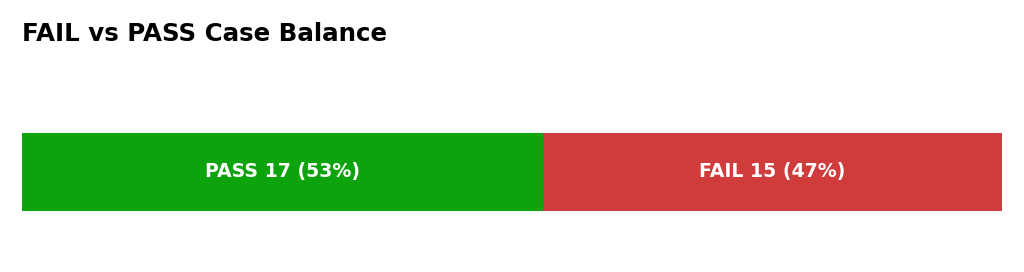

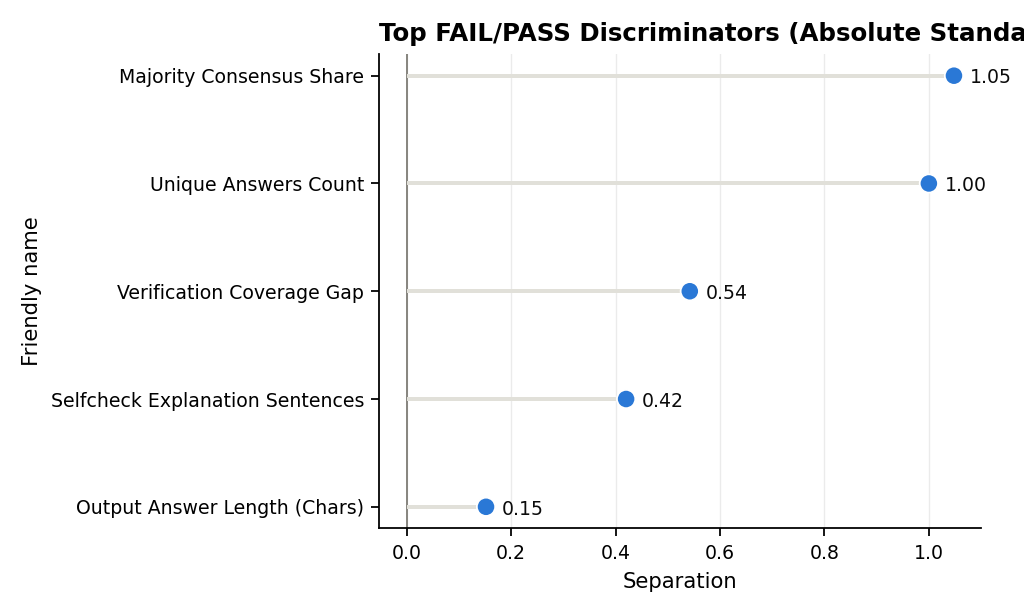

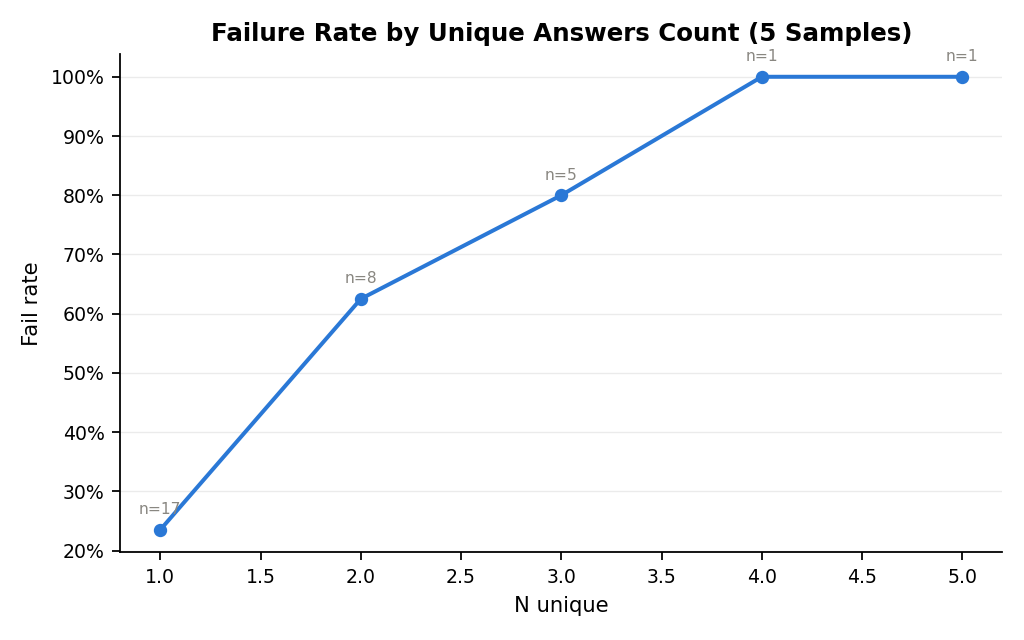

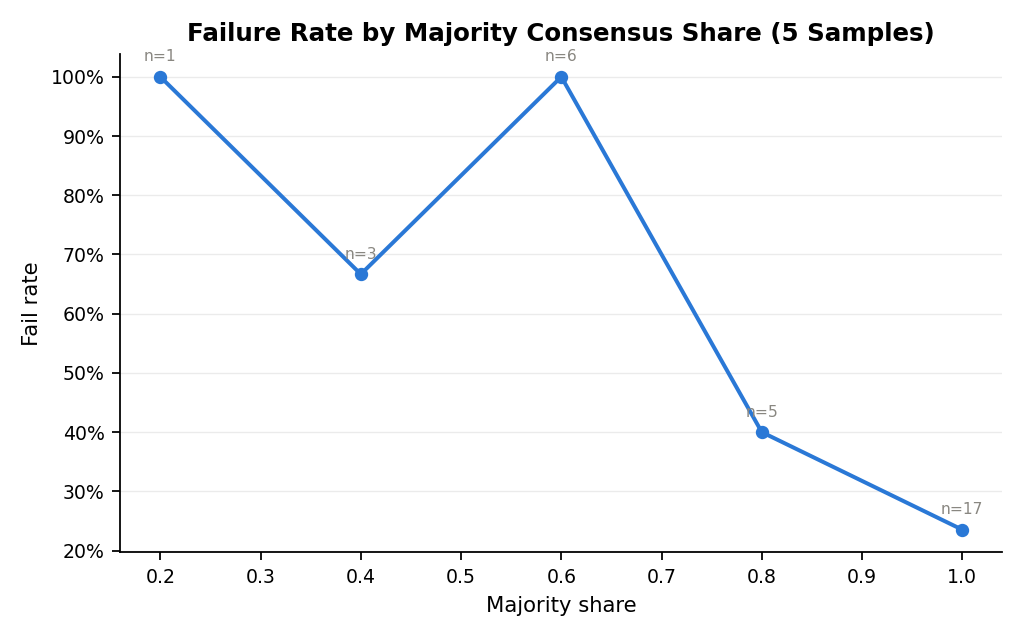

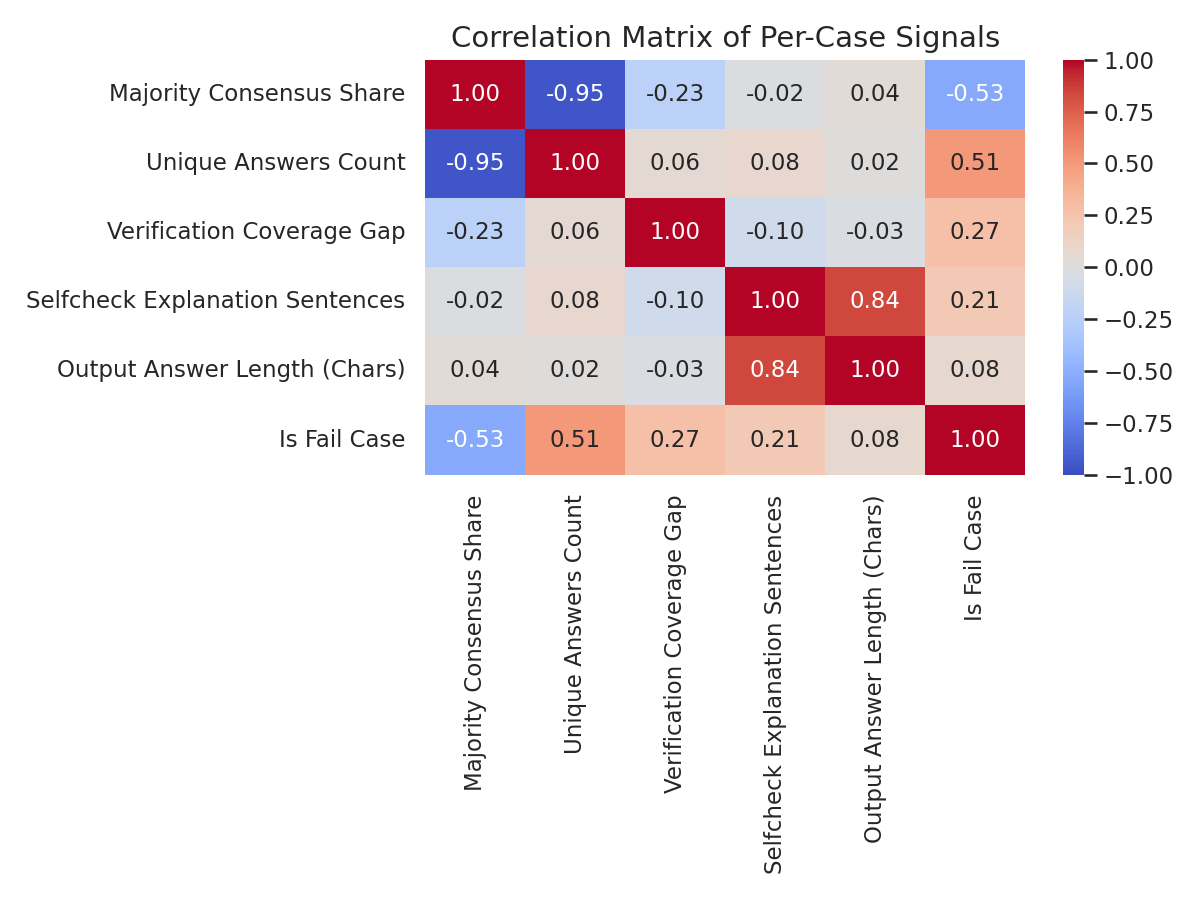

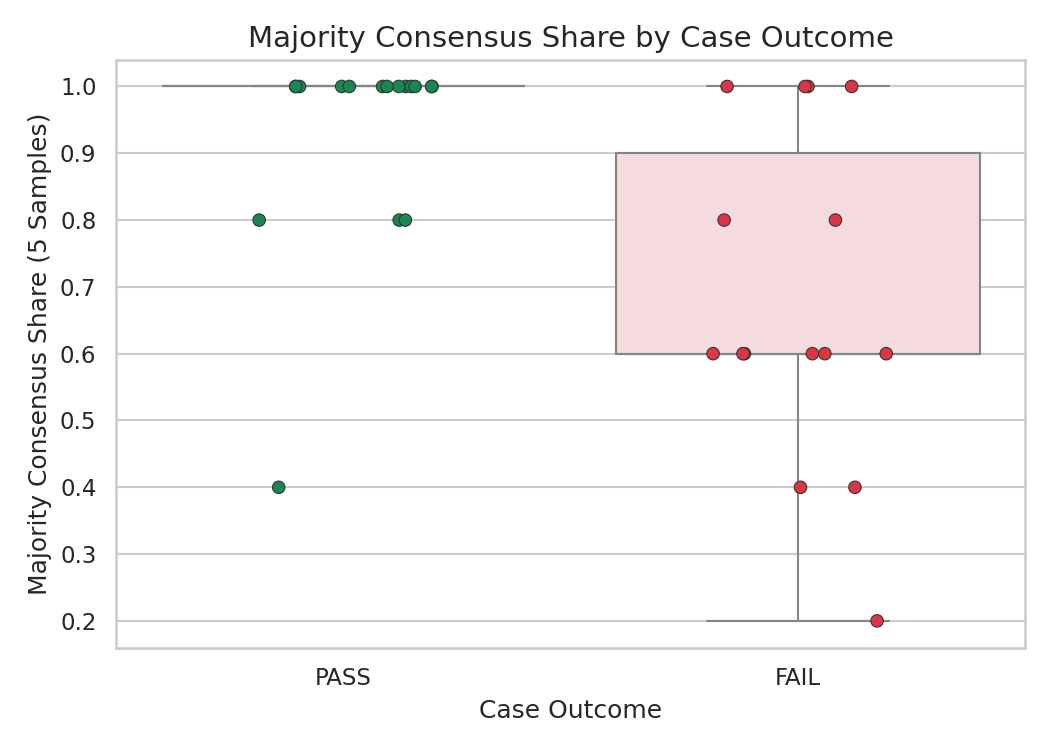

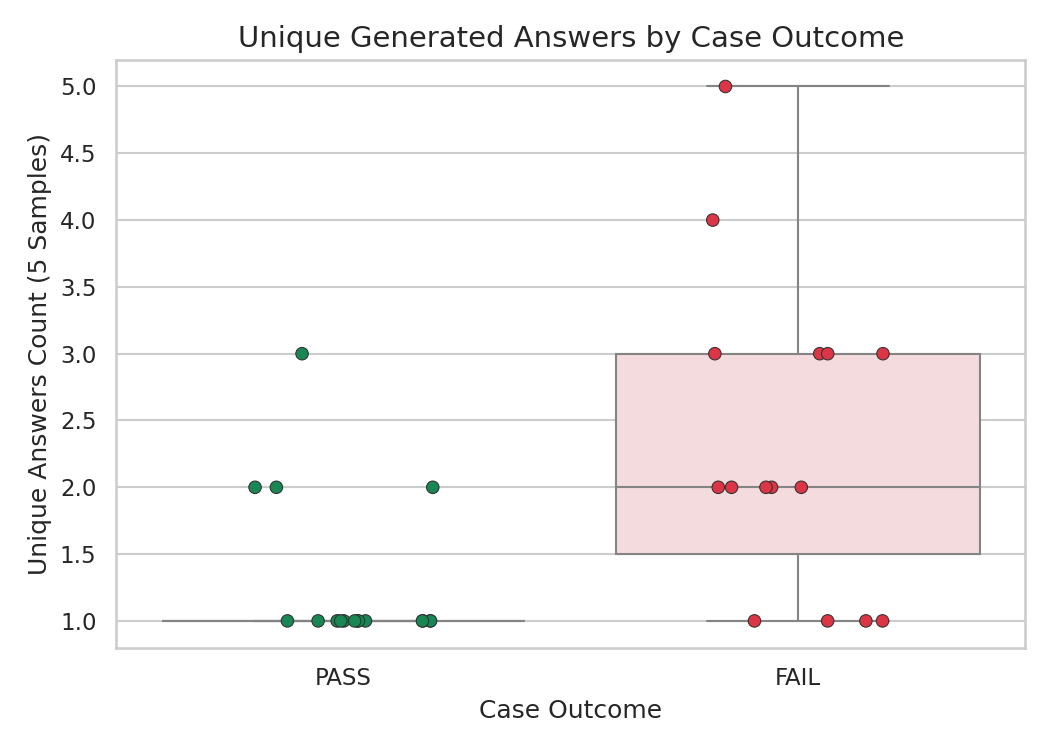

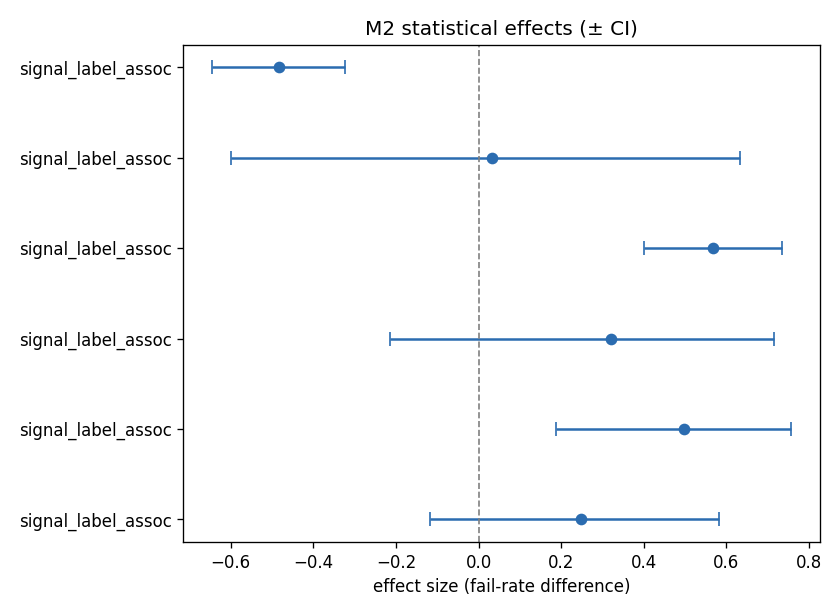

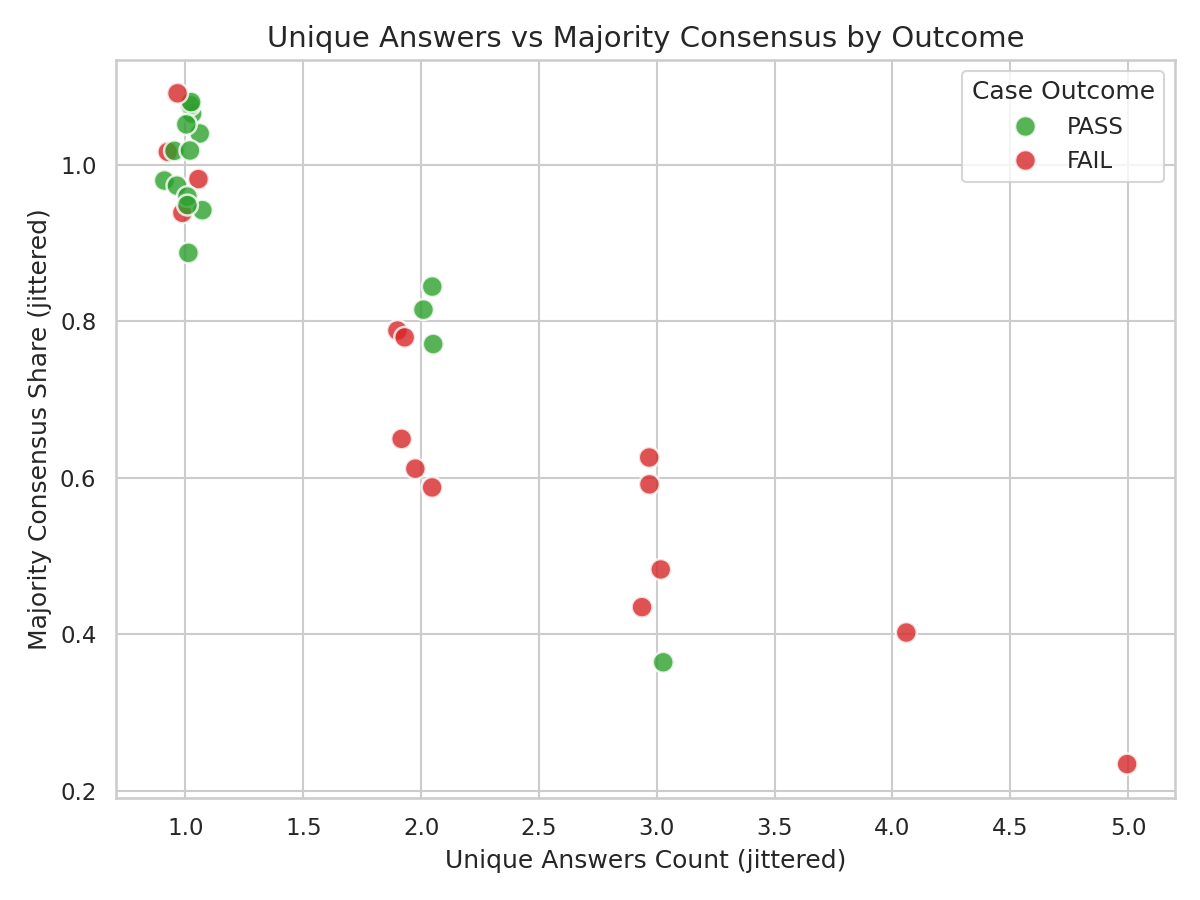

In [4]:
import json
import pandas as pd
from IPython.display import display, Markdown, Image, JSON

run_dir = Path('/content/evalrx_demo/runs/gemma-4-e2b/chartqa.notebook')
read_json = lambda p: json.loads(p.read_text())
baseline = read_json(run_dir / 'baseline.json')
summary = read_json(run_dir / 'summary.json')
stages = {stage: read_json(run_dir / 'logs' / stage / 'log.json')
          for stage in ['M1', 'M2', 'M3', 'M4', 'M5']
          if (run_dir / 'logs' / stage / 'log.json').exists()}
fix = (stages.get('M5', {}).get('fix') or [{}])[-1]
attempts = fix.get('attempted', [])
print(f"Baseline: {baseline['n_pass']}/{baseline['n']} ({baseline['accuracy']:.1%})")
print(f"Verified hypotheses: {summary['n_verified']}")
print('Frozen candidate:', fix.get('selected_on_explore') or 'none')
if attempts:
    final = attempts[0]
    display(pd.DataFrame([{
        'split': 'CONFIRM', 'n': final['n_pairs'],
        'baseline_correct': final['n_baseline_correct'],
        'candidate_correct': final['n_candidate_correct'],
        'repaired_cases': final['n_fixed'], 'regressed_cases': final['n_broken'],
        'e_value': final['e_value'], 'required_e_value': final['e_threshold'],
        'verdict': final['verdict'], 'validated_fix': final['fixed'],
    }]))
    display(JSON(final['payload']))
    print('Accuracy repair validated.' if final['fixed'] else 'No statistically confirmed accuracy repair.')
else:
    print('No candidate selected for CONFIRM; no validated accuracy repair.')
if fix.get('selection_attempted'):
    display(Markdown('### EXPLORE candidates (selection only)'))
    display(pd.DataFrame(fix['selection_attempted']))
for image in sorted((run_dir / 'logs/M2/artifacts').glob('*.png')):
    display(Image(filename=str(image)))


## 5. Inspect every answer

These tables are generated from this run and saved in the notebook output, so a reader does not need separate result files.

In [5]:
manifest = read_json(Path('/content/evalrx_demo/data/chartqa/manifest.json'))
questions = {row['id']: row['prompt'] for row in manifest}
rows = [{**row, 'question': questions[row['id']]} for row in baseline['cases']]
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(pd.DataFrame(rows)[['id', 'question', 'expected', 'observed', 'label']])
    if attempts:
        before = {row['id']: row for row in baseline['cases']}
        display(pd.DataFrame([{
            'id': cid, 'expected': before[cid]['expected'],
            'baseline': before[cid]['observed'], 'candidate': answer,
            'repaired': cid in final['fixed_cases'], 'regressed': cid in final['broken_cases'],
        } for cid, answer in final['outputs'].items()]))


,id,question,expected,observed,label
0,chartqa-human-1142,Work out the ratio of the bigger segment to the smaller one? Answer with only the short answer.,[1.577],1.8,fail
1,chartqa-human-445,In which country the difference between blue and green bar is maximum? Answer with only the short answer.,[U.S.],U.S.,pass
2,chartqa-human-709,What is the value of the highest point? Answer with only the short answer.,[19.7],19.7%,pass
3,chartqa-human-86,Which two values are same in the upper graph? Answer with only the short answer.,[77],77 and 77,fail
4,chartqa-human-576,Which country does the green line represent? Answer with only the short answer.,[Spain],Spain,pass
5,chartqa-human-45,What's the average of last three values in green graph (round to one decimal)? Answer with only the short answer.,[28.6],25.3,fail
6,chartqa-human-1122,Which category the three bars value is above 25% ? Answer with only the short answer.,[Russia],Business owners,fail
7,chartqa-human-698,Which is represented by yellow color? Answer with only the short answer.,[Netherlands],Netherlands,pass
8,chartqa-human-428,How many countries are shown in the graph? Answer with only the short answer.,[3],3,pass
9,chartqa-human-228,Which country has longest bar? Answer with only the short answer.,[Lithuania],Lithuania,pass


## 6. Full stage records

Expand these records for probe results, hypotheses, verification verdicts and repair outputs. Save the executed notebook to keep the console, tables, figure and records together. Runtime scratch files stay under `/content/evalrx_demo`; none are needed to read this notebook.

In [6]:
display(JSON({'baseline': baseline, 'summary': summary, 'stages': stages}))
for source in sorted(run_dir.rglob('*.py')):
    print('\n---', source.relative_to(run_dir), '---')
    print(source.read_text())


<IPython.core.display.JSON object>